In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
warnings.filterwarnings('ignore')

In [2]:
df= pd.read_csv('C:/Users/cjmwo/meituan/train .csv')

In [3]:
import pandas as pd

df = pd.read_csv('C:/Users/cjmwo/meituan/train .csv')

print(type(df))        # 应该是 DataFrame
print(df.shape)        # 行列数
print(df.head())       # 前5行
print(df.nunique())    # 每列类别数

<class 'pandas.core.frame.DataFrame'>
(532671, 47)
   id  loanAmnt  term  interestRate  installment grade subGrade  \
0   0   35000.0     5         19.52       917.97     E       E2   
1   1   18000.0     5         18.49       461.90     D       D2   
2   2   12000.0     5         16.99       298.17     D       D3   
3   3   11000.0     3          7.26       340.96     A       A4   
4   4    3000.0     3         12.99       101.07     C       C2   

   employmentTitle employmentLength  homeOwnership  ...    n5    n6    n7  \
0            320.0          2 years              2  ...   9.0   8.0   4.0   
1         219843.0          5 years              0  ...   NaN   NaN   NaN   
2          31698.0          8 years              0  ...   0.0  21.0   4.0   
3          46854.0        10+ years              1  ...  16.0   4.0   7.0   
4             54.0              NaN              1  ...   4.0   9.0  10.0   

     n8   n9   n10  n11  n12  n13  n14  
0  12.0  2.0   7.0  0.0  0.0  0.0  2.0  
1

In [4]:
id_cols = []
cat_cols = []
num_cols = []
high_card_cols = []

for col in df.columns:
    nunique = df[col].nunique()
    
    if nunique == df.shape[0]:
        id_cols.append(col)
    elif nunique < 20:
        cat_cols.append(col)
    elif nunique < 1000:
        num_cols.append(col)
    else:
        high_card_cols.append(col)

print("ID:", id_cols)
print("分类:", cat_cols)
print("数值:", num_cols)
print("高基数:", high_card_cols)

ID: ['id']
分类: ['term', 'grade', 'employmentLength', 'homeOwnership', 'verificationStatus', 'isDefault', 'purpose', 'pubRecBankruptcies', 'initialListStatus', 'applicationType', 'policyCode', 'n11', 'n12']
数值: ['interestRate', 'subGrade', 'issueDate', 'postCode', 'regionCode', 'delinquency_2years', 'ficoRangeLow', 'ficoRangeHigh', 'openAcc', 'pubRec', 'totalAcc', 'earliesCreditLine', 'n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9', 'n10', 'n13', 'n14']
高基数: ['loanAmnt', 'installment', 'employmentTitle', 'annualIncome', 'dti', 'revolBal', 'revolUtil', 'title']


In [5]:
df.duplicated().sum()

0

n11                   0.087365
employmentLength      0.058685
n14                   0.050594
n8                    0.050594
n2                    0.050594
n3                    0.050594
n5                    0.050594
n6                    0.050594
n0                    0.050594
n7                    0.050594
n9                    0.050594
n12                   0.050594
n13                   0.050594
n1                    0.050594
n10                   0.041731
n4                    0.041731
revolUtil             0.000663
pubRecBankruptcies    0.000497
dti                   0.000289
postCode              0.000004
title                 0.000004
employmentTitle       0.000002
policyCode            0.000002
applicationType       0.000002
initialListStatus     0.000002
totalAcc              0.000002
revolBal              0.000002
pubRec                0.000002
openAcc               0.000002
ficoRangeHigh         0.000002
ficoRangeLow          0.000002
delinquency_2years    0.000002
regionCo

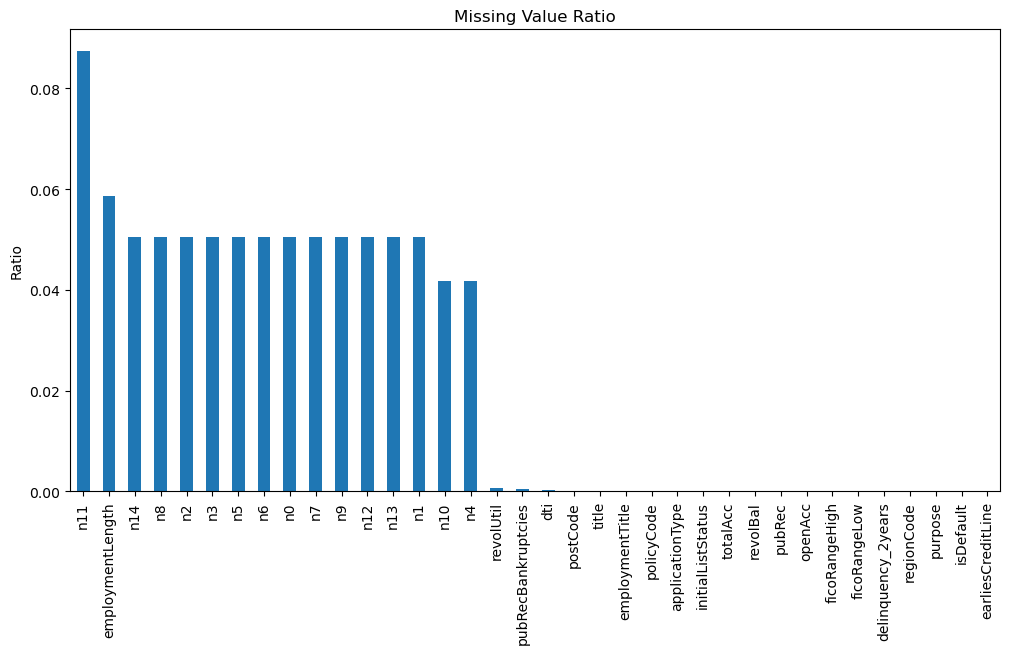

In [6]:
import pandas as pd
import matplotlib.pyplot as plt



# 2. 计算缺失比例
missing_ratio = df.isnull().mean()

# 3. 只保留有缺失的列
missing_ratio = missing_ratio[missing_ratio > 0].sort_values(ascending=False)

print(missing_ratio)

# 4. 画图
plt.figure(figsize=(12,6))
missing_ratio.plot(kind='bar')

plt.title('Missing Value Ratio')
plt.ylabel('Ratio')
plt.xticks(rotation=90)

plt.show()

In [7]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]

print("常数列（只有1个取值）：")
print(constant_cols)

常数列（只有1个取值）：
['policyCode']


In [8]:
cols_mode_fill = [
    'term', 'grade', 'homeOwnership',
    'verificationStatus', 'purpose',
    'pubRecBankruptcies', 'initialListStatus',
    'applicationType', 'policyCode', 'n11', 'n12'
]

In [9]:
mode_values = df[cols_mode_fill].mode().iloc[0]

df[cols_mode_fill] = df[cols_mode_fill].fillna(mode_values)

In [10]:
df[cols_mode_fill].isnull().sum()

term                  0
grade                 0
homeOwnership         0
verificationStatus    0
purpose               0
pubRecBankruptcies    0
initialListStatus     0
applicationType       0
policyCode            0
n11                   0
n12                   0
dtype: int64

In [11]:
import datetime
import pandas as pd

# 1. 转换时间格式
df['issueDate'] = pd.to_datetime(df['issueDate'], format='%Y-%m-%d', errors='coerce')

# 2. 基准时间
startdate = datetime.datetime.strptime('2007-06-01', '%Y-%m-%d')

# 3. 构造时间差特征（天数）
df['issueDateDT'] = (df['issueDate'] - startdate).dt.days

In [12]:
df[['issueDate', 'issueDateDT']].head()

,issueDate,issueDateDT
0,2014-07-01,2587.0
1,2012-08-01,1888.0
2,2015-10-01,3044.0
3,2015-08-01,2983.0
4,2016-03-01,3196.0


In [13]:
df[['issueDate', 'issueDateDT']].describe()

,issueDate,issueDateDT
count,532670,532670.000000
mean,2015-06-06 00:39:50.529220608,2927.027668
min,2007-07-01 00:00:00,30.000000
25%,2014-07-01 00:00:00,2587.000000
50%,2015-08-01 00:00:00,2983.000000
75%,2016-07-01 00:00:00,3318.000000
max,2018-12-01 00:00:00,4201.000000
std,NaN,591.328054


In [14]:
df[['issueDate', 'issueDateDT']].isnull().sum()

issueDate      1
issueDateDT    1
dtype: int64

In [15]:
df['employmentLength'].value_counts(dropna=False).sort_index()

employmentLength
1 year        34934
10+ years    174992
2 years       48189
3 years       42508
4 years       32000
5 years       33309
6 years       24846
7 years       23552
8 years       23931
9 years       20153
< 1 year      42997
NaN           31260
Name: count, dtype: int64

In [16]:
map_dict = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}

df['employmentLength'] = df['employmentLength'].map(map_dict)

# 缺失值处理
df['employmentLength'] = df['employmentLength'].fillna(-1)

In [17]:
df['employmentLength'].isnull().sum()

0

In [18]:
df['earliesCreditLine'].sample(5)

204356    Aug-1998
274025    Dec-1990
270077    Jul-2006
295813    Aug-2004
501137    Nov-1993
Name: earliesCreditLine, dtype: object

In [19]:
df['earliesCreditLine'] = df['earliesCreditLine'].apply(
    lambda s: int(str(s)[-4:]) if pd.notnull(s) else None
)

In [20]:
df['earliesCreditLine'].head()
df['earliesCreditLine'].dtype

dtype('float64')

In [21]:
cate_features = [
    'grade', 'subGrade', 'employmentTitle',
    'homeOwnership', 'verificationStatus', 'purpose',
    'postCode', 'regionCode',
    'applicationType', 'initialListStatus',
    'title', 'policyCode'
]

for f in cate_features:
    if f in df.columns:   # 防止列不存在报错
        print(f, '类型数：', df[f].nunique())

grade 类型数： 7
subGrade 类型数： 35
employmentTitle 类型数： 178838
homeOwnership 类型数： 6
verificationStatus 类型数： 3
purpose 类型数： 14
postCode 类型数： 923
regionCode 类型数： 51
applicationType 类型数： 2
initialListStatus 类型数： 2
title 类型数： 28049
policyCode 类型数： 1


In [22]:
df.head(100)

,id,loanAmnt,term,interestRate,installment,grade,subGrade,employmentTitle,employmentLength,homeOwnership,...,n6,n7,n8,n9,n10,n11,n12,n13,n14,issueDateDT
0,0,35000.0,5,19.52,917.97,E,E2,320.0,2.0,2,...,8.0,4.0,12.0,2.0,7.0,0.0,0.0,0.0,2.0,2587.0
1,1,18000.0,5,18.49,461.90,D,D2,219843.0,5.0,0,...,NaN,NaN,NaN,NaN,13.0,0.0,0.0,NaN,NaN,1888.0
2,2,12000.0,5,16.99,298.17,D,D3,31698.0,8.0,0,...,21.0,4.0,5.0,3.0,11.0,0.0,0.0,0.0,4.0,3044.0
3,3,11000.0,3,7.26,340.96,A,A4,46854.0,10.0,1,...,4.0,7.0,21.0,6.0,9.0,0.0,0.0,0.0,1.0,2983.0
4,4,3000.0,3,12.99,101.07,C,C2,54.0,-1.0,1,...,9.0,10.0,15.0,7.0,12.0,0.0,0.0,0.0,4.0,3196.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,95,12125.0,3,15.61,423.95,D,D1,21644.0,8.0,0,...,24.0,10.0,18.0,8.0,12.0,0.0,0.0,0.0,4.0,2618.0
96,96,25000.0,3,6.49,766.12,A,A2,4290.0,10.0,0,...,7.0,9.0,11.0,5.0,13.0,0.0,0.0,0.0,2.0,2771.0
97,97,10000.0,3,12.99,336.90,B,B4,264555.0,0.0,1,...,1.0,10.0,11.0,9.0,10.0,0.0,0.0,0.0,2.0,2284.0
98,98,10000.0,3,13.99,341.73,C,C3,199.0,4.0,1,...,4.0,6.0,9.0,4.0,8.0,0.0,0.0,0.0,5.0,3471.0


In [23]:
df.isnull().sum()

id                        0
loanAmnt                  0
term                      0
interestRate              0
installment               0
grade                     0
subGrade                  0
employmentTitle           1
employmentLength          0
homeOwnership             0
annualIncome              0
verificationStatus        0
issueDate                 1
isDefault                 1
purpose                   0
postCode                  2
regionCode                1
dti                     154
delinquency_2years        1
ficoRangeLow              1
ficoRangeHigh             1
openAcc                   1
pubRec                    1
pubRecBankruptcies        0
revolBal                  1
revolUtil               353
totalAcc                  1
initialListStatus         0
applicationType           0
earliesCreditLine         1
title                     2
policyCode                0
n0                    26950
n1                    26950
n2                    26950
n3                  

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 532671 entries, 0 to 532670
Data columns (total 48 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   id                  532671 non-null  int64         
 1   loanAmnt            532671 non-null  float64       
 2   term                532671 non-null  int64         
 3   interestRate        532671 non-null  float64       
 4   installment         532671 non-null  float64       
 5   grade               532671 non-null  object        
 6   subGrade            532671 non-null  object        
 7   employmentTitle     532670 non-null  float64       
 8   employmentLength    532671 non-null  float64       
 9   homeOwnership       532671 non-null  int64         
 10  annualIncome        532671 non-null  float64       
 11  verificationStatus  532671 non-null  int64         
 12  issueDate           532670 non-null  datetime64[ns]
 13  isDefault           532670 no

In [77]:
import pandas as pd

# n列
n_cols = [f'n{i}' for i in range(15)]

# 逐列用众数填补缺失
for col in n_cols:
    if col in df.columns and df[col].isnull().any():
        mode_val = df[col].mode()
        if len(mode_val) > 0:
            df[col] = df[col].fillna(mode_val[0])

In [79]:
df.isnull().sum().sum()

524

In [81]:
df = df.dropna()

In [83]:
df.isnull().sum().sum()

0

In [85]:
df.shape

(532163, 48)

In [89]:
df.head()

,id,loanAmnt,term,interestRate,installment,grade,subGrade,employmentTitle,employmentLength,homeOwnership,...,n6,n7,n8,n9,n10,n11,n12,n13,n14,issueDateDT
0,0,35000.0,5,19.52,917.97,E,E2,320.0,2.0,2,...,8.0,4.0,12.0,2.0,7.0,0.0,0.0,0.0,2.0,2587.0
1,1,18000.0,5,18.49,461.90,D,D2,219843.0,5.0,0,...,4.0,6.0,11.0,4.0,13.0,0.0,0.0,0.0,1.0,1888.0
2,2,12000.0,5,16.99,298.17,D,D3,31698.0,8.0,0,...,21.0,4.0,5.0,3.0,11.0,0.0,0.0,0.0,4.0,3044.0
3,3,11000.0,3,7.26,340.96,A,A4,46854.0,10.0,1,...,4.0,7.0,21.0,6.0,9.0,0.0,0.0,0.0,1.0,2983.0
4,4,3000.0,3,12.99,101.07,C,C2,54.0,-1.0,1,...,9.0,10.0,15.0,7.0,12.0,0.0,0.0,0.0,4.0,3196.0


In [91]:
df.to_csv('train1.csv', index=False)

In [92]:
import os

print(os.path.exists('train1.csv'))

True
